# Notebook 01 — Data Ingestion
**Project: Coastal Property Catastrophe Loss Model**

Pull NFIP flood claims and policies from the OpenFEMA API, download NOAA storm event data, and join them together to create a rich training dataset.

## What We're Building
- ~500K NFIP claims records for major coastal states (FL, TX, LA, NC, SC)
- NOAA storm events 2000–2023 (hurricanes, tropical storms, coastal floods)
- Joined dataset: each claim linked to its causative storm event

## Data Sources
| Source | Records | URL |
|---|---|---|
| OpenFEMA NFIP Claims | ~2.5M total | https://www.fema.gov/openfema-data-page/fima-nfip-redacted-claims-v2 |
| OpenFEMA NFIP Policies | ~60M total | https://www.fema.gov/openfema-data-page/fima-nfip-redacted-policies-v2 |
| NOAA Storm Events | ~1.7M events | https://www.ncei.noaa.gov/pub/data/swdi/stormevents/csvfiles |


In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import logging
import warnings

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')

from data_ingestion import NFIPClient, NOAAClient, ClaimsEventJoiner, load_nfip_data

# Output paths
DATA_DIR = Path('../data/raw')
DATA_DIR.mkdir(parents=True, exist_ok=True)

print('✅ Imports OK')
print(f'Data directory: {DATA_DIR.resolve()}')

✅ Imports OK
Data directory: C:\Users\jakem\OneDrive\Documents\1- Project\Marginal PML\data\raw


## 1. Check Available Data Volume

In [2]:
client = NFIPClient()

# Check record counts for target states before downloading
target_states = ['FL', 'TX', 'LA', 'NC', 'SC', 'GA', 'NJ', 'NY']
year_range = (2000, 2023)

print(f'NFIP Claims counts for {year_range[0]}–{year_range[1]}:')
print('-' * 40)

counts = {}
for state in target_states:
    n = client.get_record_count('FimaNfipClaims', state=state,
                                 start_year=year_range[0], end_year=year_range[1])
    counts[state] = n
    print(f'  {state}: {n:>10,}')

total = sum(v for v in counts.values() if v > 0)
print(f'\n  TOTAL: {total:>10,}')

NFIP Claims counts for 2000–2023:
----------------------------------------
  FL:    234,413
  TX:    265,703
  LA:    326,277
  NC:     57,905
  SC:     22,939
  GA:     13,723
  NJ:    134,700
  NY:    110,753

  TOTAL:  1,166,413


## 2. Download NFIP Claims

In [3]:
# Download claims — set limit_per_state for faster development runs
# Use limit_per_state=None for the full dataset (takes ~20 mins)
LIMIT_PER_STATE = 50_000  # Set to None for full pull

claims_raw = load_nfip_data(
    states=target_states,
    start_year=2000,
    end_year=2023,
    limit_per_state=LIMIT_PER_STATE,
    cache_dir=str(DATA_DIR),
    join_storms=True,   # Join to NOAA storm events
    verbose=True,
)

print(f'\nDataset shape: {claims_raw.shape}')
print(f'Columns: {list(claims_raw.columns)}')

INFO: Loading NFIP data for states: ['FL', 'TX', 'LA', 'NC', 'SC', 'GA', 'NJ', 'NY'], years: 2000–2023
INFO: Loading claims from cache: ..\data\raw/nfip_claims_FL_2000_2023.csv
INFO:   FL: 50,000 claims
INFO: Loading claims from cache: ..\data\raw/nfip_claims_TX_2000_2023.csv
INFO:   TX: 50,000 claims
INFO: Loading claims from cache: ..\data\raw/nfip_claims_LA_2000_2023.csv
INFO:   LA: 50,000 claims
INFO: Loading claims from cache: ..\data\raw/nfip_claims_NC_2000_2023.csv
INFO:   NC: 50,000 claims
INFO: Loading claims from cache: ..\data\raw/nfip_claims_SC_2000_2023.csv
INFO:   SC: 22,939 claims
INFO: Loading claims from cache: ..\data\raw/nfip_claims_GA_2000_2023.csv
INFO:   GA: 13,723 claims
INFO: Loading claims from cache: ..\data\raw/nfip_claims_NJ_2000_2023.csv
INFO:   NJ: 50,000 claims
INFO: Loading claims from cache: ..\data\raw/nfip_claims_NY_2000_2023.csv
INFO:   NY: 50,000 claims
INFO: 
Total claims: 336,662
INFO: Loading storm events from cache: ..\data\raw/noaa_storms_2000_


Dataset shape: (336662, 37)
Columns: ['dateOfLoss', 'yearOfLoss', 'reportedCity', 'reportedState', 'countyCode', 'floodZone', 'occupancyType', 'buildingDamageAmount', 'contentsDamageAmount', 'amountPaidOnBuildingClaim', 'amountPaidOnContentsClaim', 'amountPaidOnIncreasedCostOfComplianceClaim', 'buildingPropertyValue', 'totalBuildingInsuranceCoverage', 'totalContentsInsuranceCoverage', 'numberOfFloorsInInsuredBuilding', 'originalConstructionDate', 'originalNBDate', 'elevationCertificateIndicator', 'basementEnclosureCrawlspaceType', 'postFIRMConstructionIndicator', 'latitude', 'longitude', 'had_claim', 'total_paid', 'flood_zone_category', 'construction_year', 'construction_era', 'building_loss_ratio', 'source_state', '_state', 'matched_storm_id', 'EVENT_TYPE', 'peril_category', 'hurricane_category', 'storm_property_damage_usd', 'storm_begin_date']


In [4]:
# Quick look at the data
print('Sample records:')
display(claims_raw.head(3))

print('\nData types:')
print(claims_raw.dtypes.to_string())

print('\nNull counts (top 15 columns with nulls):')
null_pct = (claims_raw.isna().sum() / len(claims_raw) * 100).sort_values(ascending=False)
print(null_pct[null_pct > 0].head(15).round(1).to_string())

Sample records:


,dateOfLoss,yearOfLoss,reportedCity,reportedState,countyCode,floodZone,occupancyType,buildingDamageAmount,contentsDamageAmount,amountPaidOnBuildingClaim,...,construction_era,building_loss_ratio,source_state,_state,matched_storm_id,EVENT_TYPE,peril_category,hurricane_category,storm_property_damage_usd,storm_begin_date
0,2008-07-13,2008,Currently Unavailable,FL,12101.0,NaN,4.0,55705.0,10773.0,55205.38,...,1980s,0.110411,FL,FL,125888.0,Flash Flood,flood,NaN,1.000000e+04,2008-07-16
1,2022-09-29,2022,Currently Unavailable,FL,12071.0,AE,11.0,103210.0,0.0,101211.10,...,pre_1970,0.411427,FL,FL,1058654.0,Hurricane (Typhoon),hurricane,4.0,7.000000e+09,2022-09-28
2,2016-10-07,2016,Currently Unavailable,FL,12009.0,AO,1.0,NaN,NaN,NaN,...,pre_1970,0.000000,FL,FL,659430.0,Tropical Storm,tropical_storm,NaN,2.000000e+09,2016-10-06



Data types:
dateOfLoss                                    datetime64[ns]
yearOfLoss                                             int64
reportedCity                                          object
reportedState                                         object
countyCode                                           float64
floodZone                                             object
occupancyType                                        float64
buildingDamageAmount                                 float64
contentsDamageAmount                                 float64
amountPaidOnBuildingClaim                            float64
amountPaidOnContentsClaim                            float64
amountPaidOnIncreasedCostOfComplianceClaim           float64
buildingPropertyValue                                float64
totalBuildingInsuranceCoverage                         int64
totalContentsInsuranceCoverage                       float64
numberOfFloorsInInsuredBuilding                      float64
originalCon

## 3. Storm Event Coverage

In [5]:
# Check how many claims were matched to storm events
matched = claims_raw['matched_storm_id'].notna().sum()
total = len(claims_raw)

print(f'Storm event match rate: {matched:,} / {total:,} = {matched/total:.1%}')
print()

# Storm type distribution
if 'EVENT_TYPE' in claims_raw.columns:
    print('Top storm event types:')
    print(claims_raw['EVENT_TYPE'].value_counts().head(10).to_string())

# Hurricane category distribution
if 'hurricane_category' in claims_raw.columns:
    print('\nHurricane category distribution:')
    cat_dist = claims_raw['hurricane_category'].value_counts(dropna=False).sort_index()
    print(cat_dist.to_string())

Storm event match rate: 304,478 / 336,662 = 90.4%

Top storm event types:
EVENT_TYPE
Flash Flood            81768
Hurricane (Typhoon)    67521
Flood                  52032
Storm Surge/Tide       50860
Coastal Flood          31153
Tropical Storm         21144

Hurricane category distribution:
hurricane_category
1.0     30410
2.0       137
3.0        41
4.0     12681
5.0       952
NaN    292441


## 4. Loss Distribution Overview

Records with building claim: 258,897 (76.9% of total)

Building claim stats:
count      $258,897
mean        $47,161
std         $79,351
min              $0
25%          $7,046
50%         $23,043
75%         $62,924
max      $9,100,033
Name: amountPaidOnBuildingClaim, dtype: object


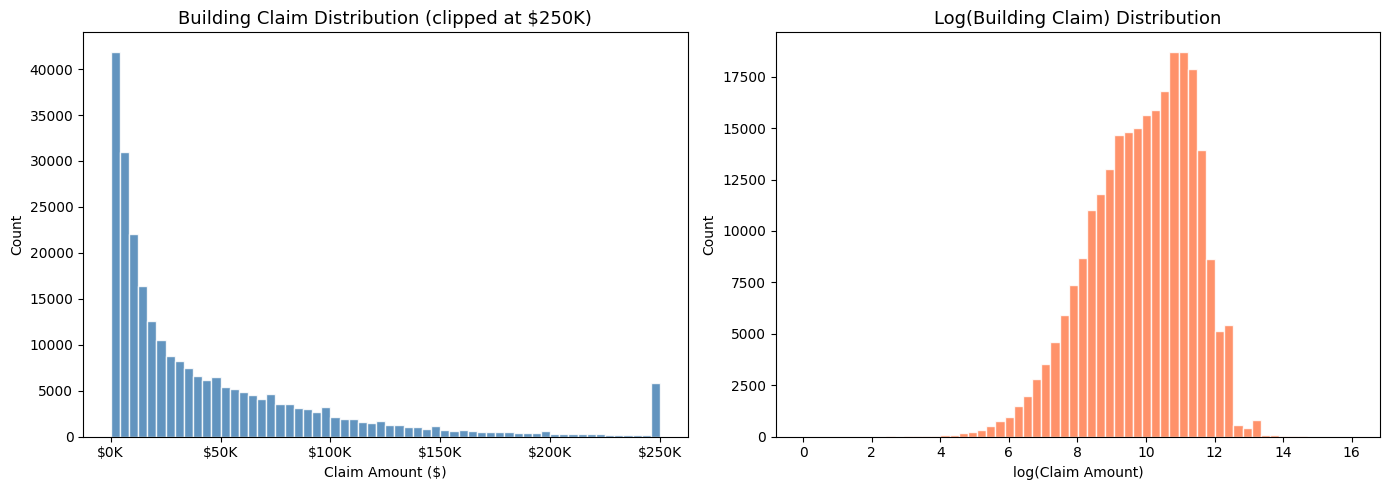


→ Log-normal distribution confirmed: log(claims) is approximately normal


In [6]:
# Filter to claims with actual paid amounts
claims_with_loss = claims_raw[claims_raw['amountPaidOnBuildingClaim'].fillna(0) > 0].copy()

print(f'Records with building claim: {len(claims_with_loss):,} ({len(claims_with_loss)/len(claims_raw):.1%} of total)')
print(f'\nBuilding claim stats:')
print(claims_with_loss['amountPaidOnBuildingClaim'].describe().apply('${:,.0f}'.format))

# Plot loss distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw distribution
axes[0].hist(claims_with_loss['amountPaidOnBuildingClaim'].clip(upper=250_000),
             bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Building Claim Distribution (clipped at $250K)', fontsize=13)
axes[0].set_xlabel('Claim Amount ($)')
axes[0].set_ylabel('Count')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

# Log distribution
log_losses = np.log(claims_with_loss['amountPaidOnBuildingClaim'].clip(lower=1))
axes[1].hist(log_losses, bins=60, color='coral', edgecolor='white', alpha=0.85)
axes[1].set_title('Log(Building Claim) Distribution', fontsize=13)
axes[1].set_xlabel('log(Claim Amount)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('../data/fig_01_loss_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n→ Log-normal distribution confirmed: log(claims) is approximately normal')

## 5. Geographic Distribution

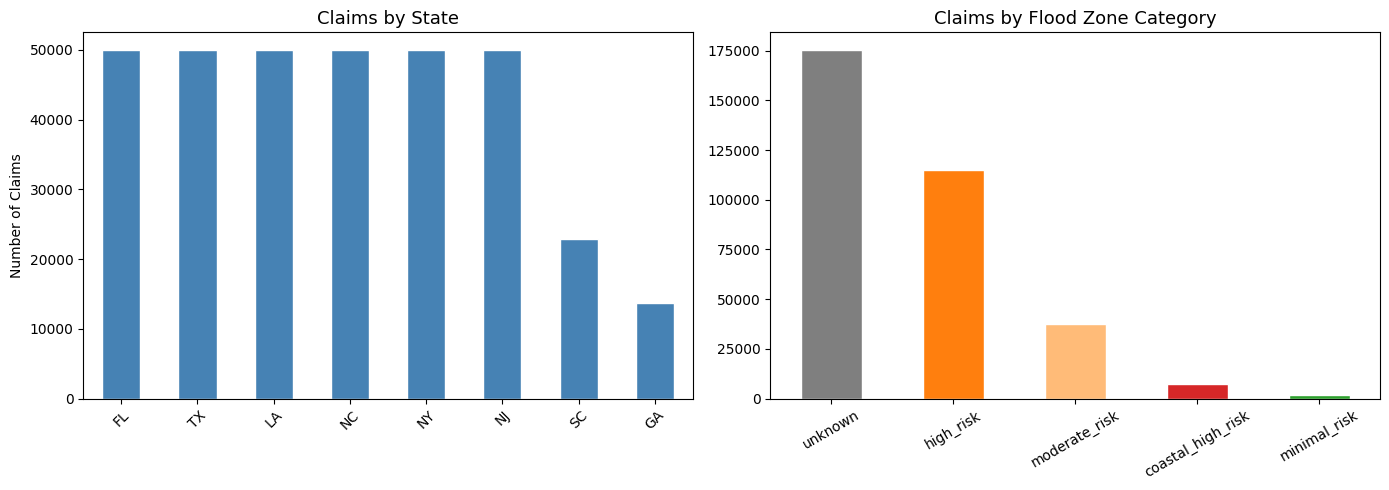

In [7]:
# Claims by state and flood zone
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Claims by state
state_counts = claims_raw['reportedState'].value_counts()
state_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Claims by State', fontsize=13)
axes[0].set_xlabel('')
axes[0].set_ylabel('Number of Claims')
axes[0].tick_params(axis='x', rotation=45)

# Claims by flood zone
if 'flood_zone_category' in claims_raw.columns:
    zone_counts = claims_raw['flood_zone_category'].value_counts()
    zone_colors = {'coastal_high_risk': '#d62728', 'high_risk': '#ff7f0e',
                   'moderate_risk': '#ffbb78', 'minimal_risk': '#2ca02c', 'unknown': '#7f7f7f'}
    colors = [zone_colors.get(z, 'gray') for z in zone_counts.index]
    zone_counts.plot(kind='bar', ax=axes[1], color=colors, edgecolor='white')
    axes[1].set_title('Claims by Flood Zone Category', fontsize=13)
    axes[1].set_xlabel('')
    axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../data/fig_01_geographic_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Save Processed Dataset

In [8]:
# Save the enriched claims dataset for use in subsequent notebooks
output_path = DATA_DIR / 'nfip_claims_enriched.parquet'
claims_raw.to_parquet(output_path, index=False)

print(f'Saved {len(claims_raw):,} records to {output_path}')
print(f'File size: {output_path.stat().st_size / 1e6:.1f} MB')

print('\n✅ Notebook 01 complete — proceed to 02_eda.ipynb')

Saved 336,662 records to ..\data\raw\nfip_claims_enriched.parquet
File size: 17.0 MB

✅ Notebook 01 complete — proceed to 02_eda.ipynb
